In [ ]:
import numpy as np
import pyref.fitting as fit
from refnx.analysis import Parameter, Parameters

from utils import read_ooc, read_xrr
from utils.profile_slab import AdaptiveOrientationProfile
from utils.slab_builders import sio2, substrate, surface, vacuum


In [ ]:
oocs = read_ooc("dft.csv", material="znpc")
data = read_xrr("reflectivity_data", material="znpc")

In [ ]:
def model(
    energy: float,
    total_thick: float = 198.2,
    surface_roughness: float = 2.8,
    density: float = 1.6153,
    characteristic_thickness: float = 8,
    max_angle: float = 0.638,
    initial_angle: float = 0,
    num_slabs: int = 20,
):
    energy = float(energy)
    return (
        vacuum(energy)  # type: ignore
        | surface(energy, oocs, thick=0, rough=0)
        | AdaptiveOrientationProfile(
            oocs,
            energy=energy,
            total_thick=total_thick,
            surface_roughness=surface_roughness,
            density=density,
            characteristic_thickness=characteristic_thickness,
            max_angle=max_angle,
            initial_angle=initial_angle,
            name=f"ZnPc_{energy:.1f}",
            num_slabs=num_slabs,
        )
        | sio2(energy)
        | substrate(energy)
    )

In [ ]:
models = {e: model(e) for e in data}

template = models["283.7"]

# Surface Layer
template.components[1].thick.setp(vary=True)
template.components[1].rough.setp(vary=True)
template.components[1].sld.density.setp(vary=True, bounds=(1.0, 1.7))

# ZnPc Layer
template.components[2].total_thick.setp(vary=True, bounds=(160, 210))
template.components[2].surface_roughness.setp(vary=True, bounds=(0, 25))
template.components[2].density.setp(value=1.6153, vary=False, bounds=(1.5, 1.7))
# template.components[2].characteristic_thickness.setp(vary=True, bounds=(6, 12))
template.components[2].max_angle.setp(vary=True, bounds=(np.pi / 2, np.pi))
template.components[2].initial_angle.setp(vary=True, bounds=(0, np.pi / 2))
# template.components[2].num_slabs.setp(vary=True, bounds=(10, 30))

# SiO2 Layer
template.components[3].thick.setp(vary=False, bounds=(0, 25))
template.components[3].rough.setp(vary=False, bounds=(0, 25))
template.components[3].sld.density.setp(vary=False)


def filt_struct(x: str) -> bool:
    if "get_" in x.lower() or "get" in x.lower():
        return False
    if "slab" in x.lower():
        return False
    return (
        "thick" in x.lower()
        or "thickness" in x.lower()
        or "rough" in x.lower()
        or "roughness" in x.lower()
    )


def filt_sld(x: str) -> bool:
    if "get_" in x.lower() or "get" in x.lower():
        return False
    return (
        "rot" in x.lower()
        or "rotation" in x.lower()
        or "angle" in x.lower()
        or "density" in x.lower()
        or "rho" in x.lower()
    )


def _link_params(slab, ref):
    # Handle structure parameters
    struct_params = list(filter(filt_struct, dir(slab)))
    for pname in struct_params:
        p = getattr(slab, pname)
        try:
            p.setp(vary=None, constraint=getattr(ref, pname))
        except Exception:
            print(f"Failed to link {pname}")
            print(slab)
            print(ref)

    sld_params_t0 = list(filter(filt_sld, dir(slab)))
    if len(sld_params_t0) != 0:
        for pname in sld_params_t0:
            p = getattr(slab, pname)
            p.setp(vary=None, constraint=getattr(ref, pname))
    sld_params_t1 = list(filter(filt_sld, dir(slab.sld)))
    if len(sld_params_t1) != 0:
        for pname in sld_params_t1:
            p = getattr(slab.sld, pname)
            p.setp(vary=None, constraint=getattr(ref.sld, pname))


def link_params(slab, ref):
    for _slab, _ref in zip(slab.components, ref.components, strict=True):
        _link_params(_slab, _ref)


for e in data:
    if e == "283.7":
        continue
    link_params(models[e], template)

In [ ]:
data.keys()

dict_keys(['282.9', '281.6', '289.0', '283.5', '281.4', '282.0', '282.3', '275.0', '284.2', '282.7', '285.1', '281.2', '283.3', '287.0', '281.8', '280.0', '283.7', '282.5', '250.0', '281.0', '283.1'])

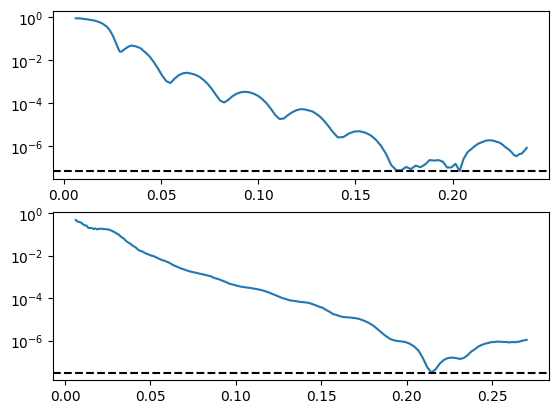

In [ ]:
import matplotlib.pyplot as plt

refl: dict[str, fit.ReflectModel] = {
    e: fit.ReflectModel(models[e], energy=float(e), pol="sp") for e in data
}
fig, ax = plt.subplots(nrows=2)
for e, ref in refl.items():
    ref.scale_s.setp(vary=True, bounds=(0.5, 2))
    ref.scale_p.setp(vary=True, bounds=(0.5, 2))
    ref.theta_offset_s.setp(vary=True, bounds=(-1, 1))
    ref.theta_offset_p.setp(vary=True, bounds=(-1, 1))
    ref.energy_offset.setp(vary=True, bounds=(-.5, .5))
    if e in ["250.0", "283.7"]:
        exp = data[e].p
        ref.bkg.setp(value=exp.y.min(), vary=False)
        i = ["250.0", "283.7"].index(e)
        ax[i].plot(exp.x, exp.y)
        ax[i].set_yscale("log")
        ax[i].axhline(
            ref.bkg.value,
            color="k",
            linestyle="--",
        )


In [ ]:
objective: list[fit.AnisotropyObjective] = [
    fit.AnisotropyObjective(
        refl[e], data[e], logp_anisotropy_weight=0.5, transform=fit.Transform("logY")
    )
    for e in data
]
global_objective = fit.GlobalObjective(objective)
print(global_objective.varying_parameters())

________________________________________________________________________________
Parameters:      None      
<Parameter:   'scale_s'   , value=1          , bounds=[0.5, 2.0]>
<Parameter:   'scale_p'   , value=1          , bounds=[0.5, 2.0]>
<Parameter:'theta_offset_s', value=0          , bounds=[-1.0, 1.0]>
<Parameter:'theta_offset_p', value=0          , bounds=[-1.0, 1.0]>
<Parameter:'Surface_283.7_thick', value=0          , bounds=[0.0, 12.0]>
<Parameter:'Surface_283.7_rough', value=0          , bounds=[0.0, 5.0]>
<Parameter:'Surface_283.7_density', value=1          , bounds=[1.0, 1.7]>
<Parameter:'Surface_283.7_rotation', value=0.8          , bounds=[0.0, 0.7853981633974483]>
<Parameter: 'total_thick' , value=198.2          , bounds=[160.0, 210.0]>
<Parameter:'surface_roughness', value=2.8          , bounds=[0.0, 25.0]>
<Parameter:  'max_angle'  , value=0.638          , bounds=[1.5707963267948966, 3.141592653589793]>
<Parameter:'initial_angle', value=0          , bounds=[0.0, 1.5707

In [35]:
from time import perf_counter

import pandas as pd
from uncertainties import ufloat

from utils.helpers.fitting_helper import aic, bic, reduced_chi2


def package_results(fitter) -> pd.DataFrame:
    params = []
    for p in fitter.objective.varying_parameters():
        err = p.stderr if p.stderr is not None else 0
        params.append(
            {
                "name": p.name,
                "value": ufloat(p.value, err),
            }
        )
    # Add fit statistics
    params.append(
        {
            "name": "reduced_chi2",
            "value": reduced_chi2(fitter.objective),
        }
    )
    params.append(
        {
            "name": "aic",
            "value": aic(fitter.objective),
        }
    )
    params.append(
        {
            "name": "bic",
            "value": bic(fitter.objective),
        }
    )
    return pd.DataFrame(params).set_index("name")


fitter = fit.CurveFitter(global_objective)

df_sparse = package_results(fitter)
df_sparse.to_csv("profile_fit_v3_initial.csv")

/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


In [ ]:
start = perf_counter()
res = fitter.fit(method="differential_evolution", updating="deferred", workers=10)
end = perf_counter()
print(f"Time taken: {end - start} seconds")

299.98015207407684: : 3it [05:11, 94.18s/it] 

In [128]:
df_output = package_results(fitter)
df_output.to_csv("profile_fit_v2_final.csv")
df_output

/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


,value
name,
scale_s,1.741592601095971+/-0.000000000000013
scale_p,0.890+/-0.012
theta_offset_s,0.108+/-0.031
theta_offset_p,-0.3592656741580338+/-0.0000000000000020
Surface_283.7_thick,5.1+/-1.5
...,...
theta_offset_s,0.196+/-0.027
theta_offset_p,0.5602937032349877+/-0
reduced_chi2,36.850502


In [114]:
from pathlib import Path

import matplotlib.pyplot as plt

from utils.helpers.plotting_helper import plot_all_results, set_plotting_defaults

set_plotting_defaults()

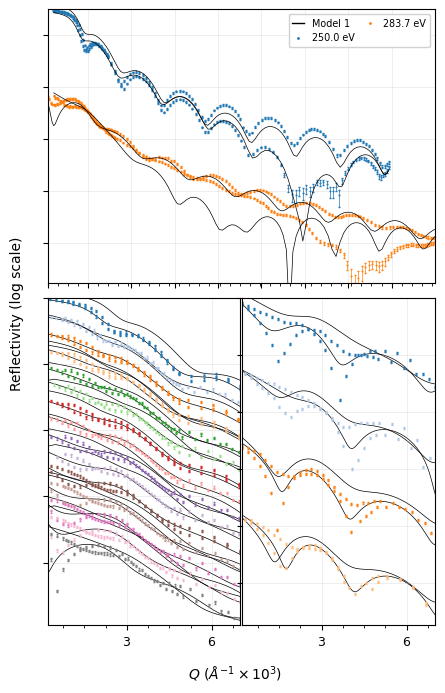

In [129]:
fig = plot_all_results(
    fitter.objective,
    data,
)
fig.set_size_inches(5, 8)

In [132]:
# seconds to time
import time

time.strftime("%H:%M:%S", time.gmtime(698))


'00:11:38'